<a href="https://colab.research.google.com/github/MoraisSn/ds-ml-projects/blob/main/praticando_dt_sc/prever_cancer_mama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:
# 1. Carregar o dataset (raw_data = dados cru)
raw_data = load_breast_cancer()

In [ ]:
# 2. Criar o DataFrame com as características (features->caracteristicas)
df = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)

In [ ]:
# 3. Adicionar a coluna de alvo (target) - O que queremos prever
# 0 = Maligno, 1 = Benigno
df['alvo'] = raw_data.target

# Visualizar as primeiras linhas
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,alvo
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
print(df['alvo'].value_counts())

alvo
1    357
0    212
Name: count, dtype: int64


In [ ]:
x = df.drop('alvo', axis=1)
y = df['alvo']
x_train, x_teste, y_train, y_test= train_test_split(x, y, test_size=0.25, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Criamos o "cérebro" vazio
# O max_iter ajuda o modelo a ter tempo de convergir (chegar numa resposta)
modelo = LogisticRegression(max_iter=10000)

# 2. Treinamos o modelo (O aprendizado acontece aqui!)
modelo.fit(x_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [ ]:
# O modelo tenta adivinhar os resultados para o conjunto de teste
previsoes = modelo.predict(x_teste)

In [ ]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, previsoes)
print(f"Acurácia do modelo: {acuracia * 100:.2f}%")

Acurácia do modelo: 96.50%


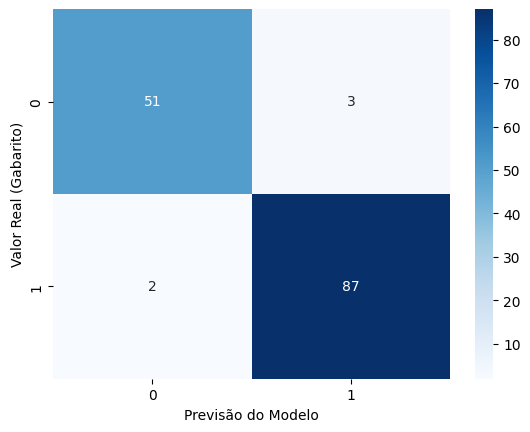

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Criando a matriz
matriz = confusion_matrix(y_test, previsoes)

# Visualizando de forma bonita
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Gabarito)')
plt.show()

Vamos interpretar a matriz de confusão que geramos:

```
matriz = [[51, 3],
          [ 2, 87]]
```

Nesta matriz:

*   **Verdadeiros Negativos (TN) - `51`**: O modelo previu corretamente que **51 casos eram negativos** (Benignos) e eles realmente eram Benignos.
*   **Falsos Positivos (FP) - `3`**: O modelo previu erroneamente que **3 casos eram negativos** (Benignos), mas na verdade eles eram positivos (Malignos). Isso é um "Erro Tipo I" ou "alarme falso".
*   **Falsos Negativos (FN) - `2`**: O modelo previu erroneamente que **2 casos eram positivos** (Malignos), mas na verdade eles eram negativos (Benignos). Isso é um "Erro Tipo II" ou "perda".
*   **Verdadeiros Positivos (TP) - `87`**: O modelo previu corretamente que **87 casos eram positivos** (Malignos) e eles realmente eram Malignos.


**Em resumo:**

*   A linha superior representa os casos reais como 'Benigno'. O modelo classificou 51 corretamente como Benigno e 3 incorretamente como Maligno.
*   A linha inferior representa os casos reais como 'Maligno'. O modelo classificou 2 incorretamente como Benigno e 87 corretamente como Maligno.

Podemos ver que o modelo teve um bom desempenho, com poucos erros de classificação. Os `51` e `87` são os acertos (diagonal principal), enquanto `3` e `2` são os erros.

In [ ]:
from sklearn.metrics import classification_report

# Gera um relatório com Precision, Recall e F1-Score
print(classification_report(y_test, previsoes, target_names=raw_data.target_names))

              precision    recall  f1-score   support

   malignant       0.96      0.94      0.95        54
      benign       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

